# Практическая работа №5

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix, recall_score, precision_score
import warnings

warnings.filterwarnings('ignore')

## EDA

In [37]:
data = pd.read_csv("../data\Smartphone_Dependence.csv")
data

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,TXN07496,U07496,26,Other,9.85,1.75,3.13,3.49,5.81,249,122,11.99,Low,Yes,Moderate,1
7496,TXN07497,U07497,35,Male,5.67,2.33,2.76,5.90,8.47,197,56,7.08,Low,No,NaN,0
7497,TXN07498,U07498,22,Female,9.99,3.61,1.09,1.16,8.17,207,24,12.84,Medium,Yes,Severe,1
7498,TXN07499,U07499,23,Male,8.74,1.59,0.07,4.64,6.19,134,62,10.52,High,Yes,Severe,1


In [38]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   str    
 1   user_id                  7500 non-null   str    
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   str    
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   str    
 13  academic_work_impact     7500 non-null   str    
 14  addiction_level          6681 non-n

In [39]:
data.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,26.568800,7.499912,3.273484,2.014183,3.242420,6.737561,134.257333,97.832400,9.243827,0.707733
std,5.197108,2.609188,1.585342,1.146039,1.600765,1.283605,66.586883,48.423349,2.718281,0.454835
min,18.000000,3.000000,0.500000,0.000000,0.500000,4.500000,20.000000,15.000000,3.580000,0.000000
25%,22.000000,5.220000,1.910000,1.020000,1.850000,5.630000,76.000000,55.000000,6.960000,0.000000
50%,27.000000,7.525000,3.270000,2.040000,3.230000,6.720000,134.000000,98.000000,9.260000,1.000000
75%,31.000000,9.810000,4.630000,2.990000,4.640000,7.840000,191.000000,140.000000,11.540000,1.000000
max,35.000000,12.000000,6.000000,4.000000,6.000000,9.000000,250.000000,180.000000,14.880000,1.000000


In [40]:
data["addiction_level"].value_counts()

addiction_level
Moderate    2874
Severe      2434
Mild        1373
Name: count, dtype: int64

Есть пропущенные значения в столбце `addiction_level`

In [41]:
mode_val = data['addiction_level'].mode()[0]
data['addiction_level'] = data['addiction_level'].fillna(mode_val, inplace=True)

In [42]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   str    
 1   user_id                  7500 non-null   str    
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   str    
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   str    
 13  academic_work_impact     7500 non-null   str    
 14  addiction_level          7500 non-n

Можно заметить, что `transaction_id` и `user_id` представляют собой просто счётсчкики, которые не несут информацию и служат индексами строк - их можно удалить

In [43]:
data = data.drop(columns = ['transaction_id', 'user_id'])

Теперь остается перекодировать `str` признаки

In [44]:
str_atr = ['gender', 'stress_level', 'academic_work_impact', 'addiction_level']
all_mappings = {}

for col in str_atr:
    unique_vals = sorted(data[col].unique())
    
    col_map = {val: idx for idx, val in enumerate(unique_vals)}
    all_mappings[col] = col_map
    
    data[col] = data[col].map(col_map)

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      7500 non-null   int64  
 1   gender                   7500 non-null   int64  
 2   daily_screen_time_hours  7500 non-null   float64
 3   social_media_hours       7500 non-null   float64
 4   gaming_hours             7500 non-null   float64
 5   work_study_hours         7500 non-null   float64
 6   sleep_hours              7500 non-null   float64
 7   notifications_per_day    7500 non-null   int64  
 8   app_opens_per_day        7500 non-null   int64  
 9   weekend_screen_time      7500 non-null   float64
 10  stress_level             7500 non-null   int64  
 11  academic_work_impact     7500 non-null   int64  
 12  addiction_level          7500 non-null   int64  
 13  addicted_label           7500 non-null   int64  
dtypes: float64(6), int64(8)
memory usag

In [45]:
sorted(data["addiction_level"].unique())

[np.int64(0), np.int64(1), np.int64(2)]

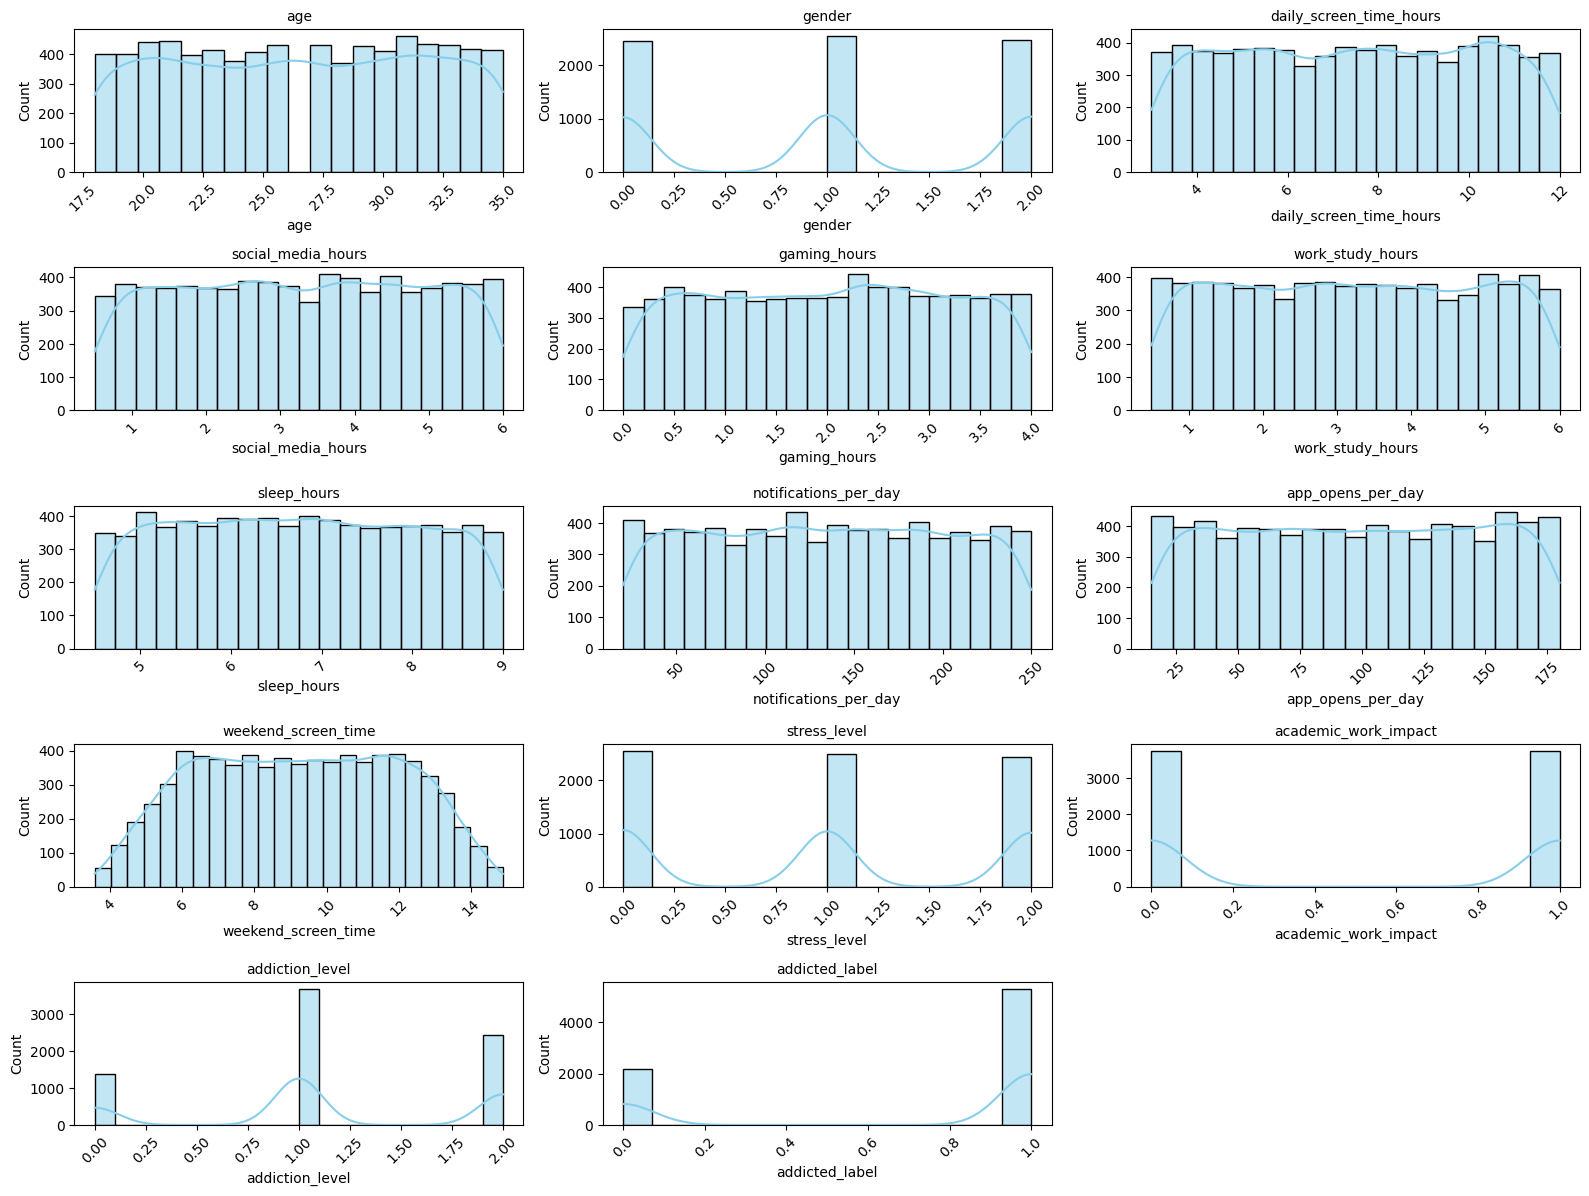

In [46]:
fig, axes = plt.subplots(5, 3, figsize=(16, 12))
axes = axes.flatten()
cols = data.columns

for i, col in enumerate(cols):
    if data[col].dtype in ['float64', 'int64']:
        sns.histplot(data[col], ax=axes[i], kde=True, color='skyblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(cols[:14]), 15):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

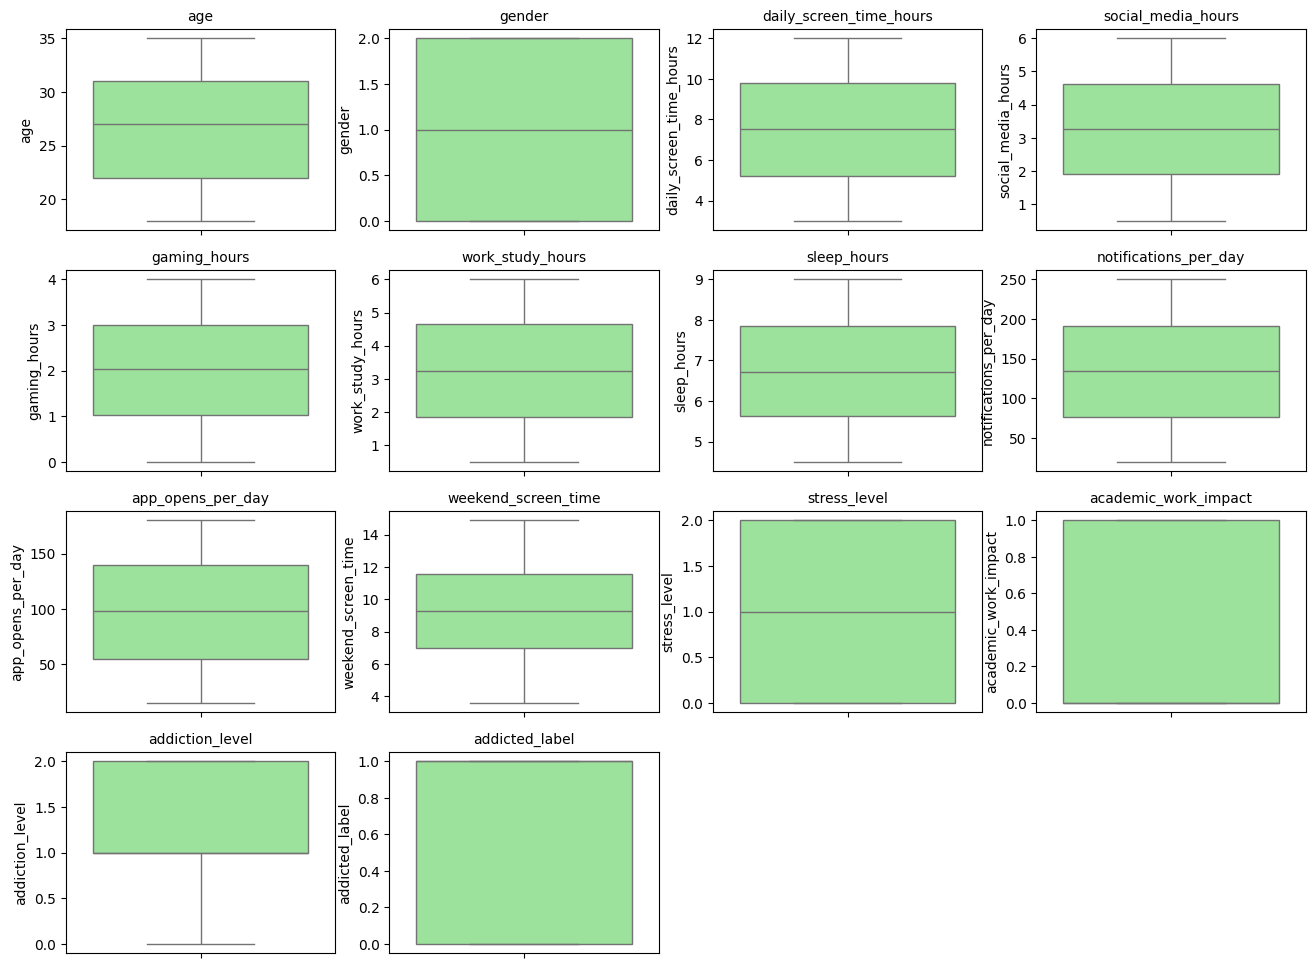

In [47]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(y=data[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(cols), 16):
    axes[j].set_visible(False)

Смотря на графики, выдно что выбросов нет. Более того, неперекодированные признаки имеют равномерное распределение

addicted_label             0.706638
daily_screen_time_hours    0.394220
weekend_screen_time        0.379028
social_media_hours         0.331725
sleep_hours                0.030698
age                        0.016920
app_opens_per_day          0.010643
gender                     0.008338
work_study_hours           0.003789
gaming_hours               0.000872
stress_level               0.000562
academic_work_impact      -0.008812
notifications_per_day     -0.009883
Name: addiction_level, dtype: float64


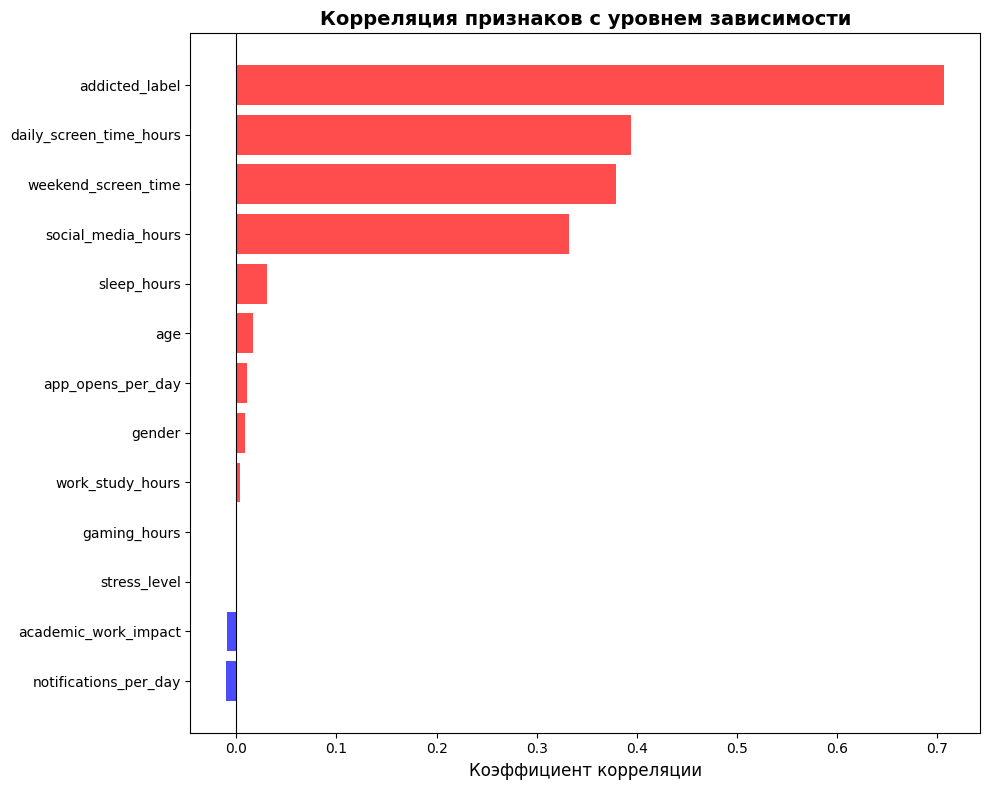

In [48]:
corr_matrix = data[cols].corr()

target_corr = corr_matrix['addiction_level'].drop('addiction_level').sort_values(ascending=False)
print(target_corr)

plt.figure(figsize=(10, 8))
colors = ['red' if x > 0 else 'blue' for x in target_corr.values]
bars = plt.barh(target_corr.index, target_corr.values, color=colors, alpha=0.7)
plt.xlabel('Коэффициент корреляции', fontsize=12)
plt.title('Корреляция признаков с уровнем зависимости', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

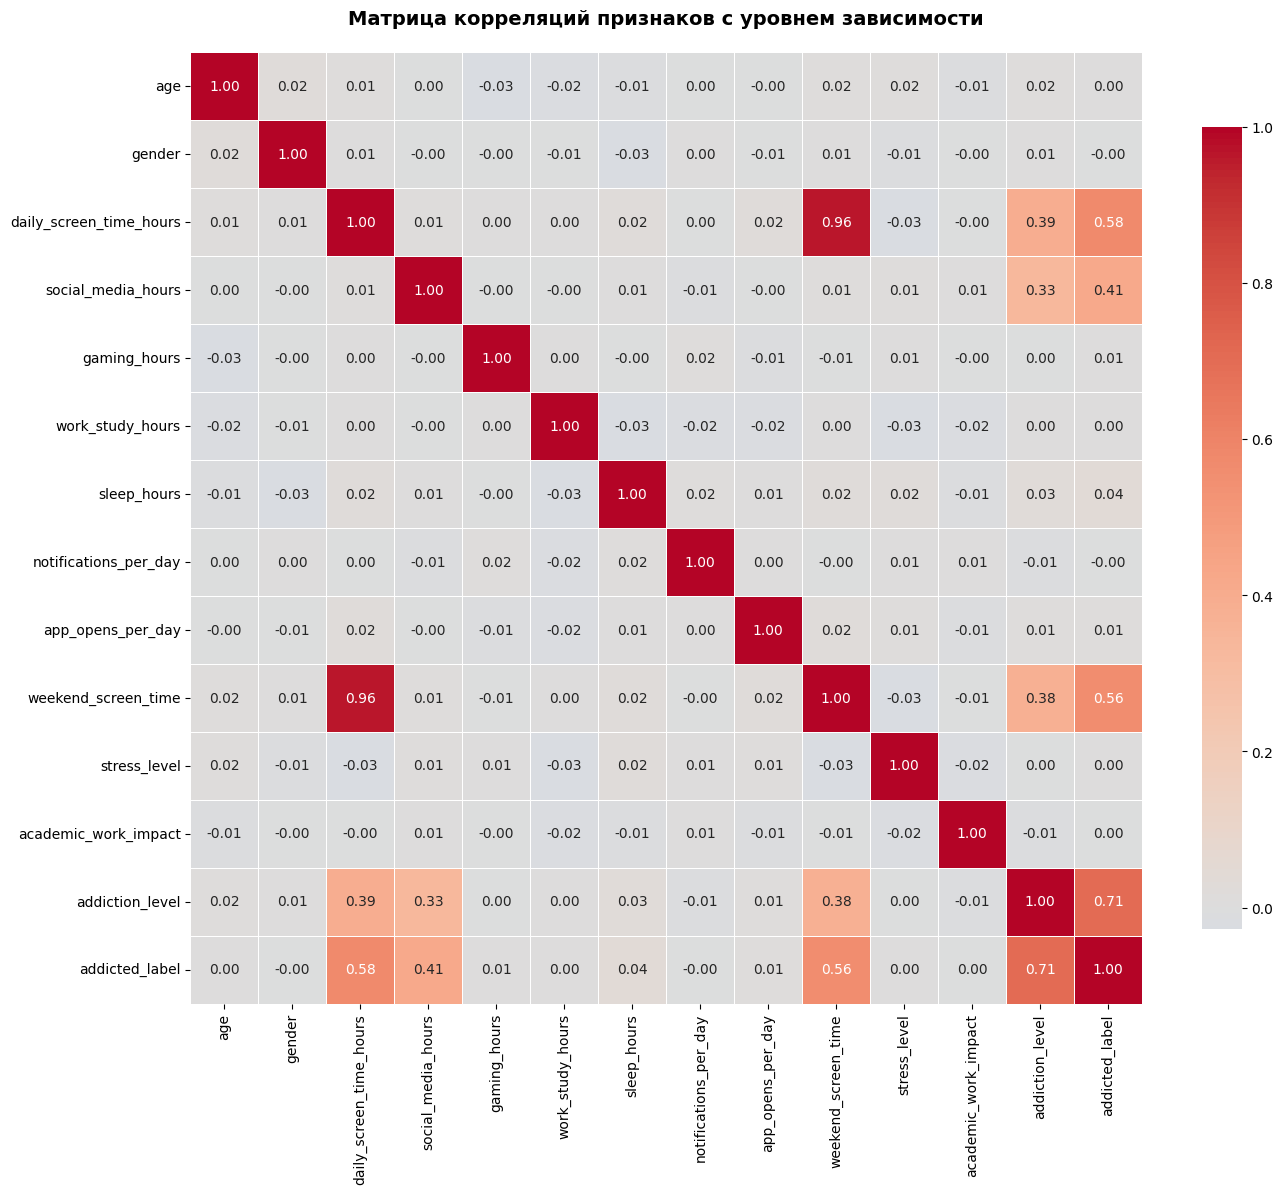

In [49]:
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=.5, square=True, cbar_kws={"shrink": .8})
plt.title('Матрица корреляций признаков с уровнем зависимости', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Из тепловой карты видно, что:

- `addicted_label` сильно коррелирует `target` (так как является его булевым предствелением)
- Наибольшие корреляции `traget` с `daily_screen_time_hours`, `weekend_screen_time`, `social_media_hours`
- Присутствует коллинеарность между `weekend_screen_time` и `daily_screen_time_hours`
=
Все остальыне корреляции незначительны

## Тренировка

In [60]:
def calculate_metrics(y_true, y_pred):
    return {
        'F1': f1_score(y_true, y_pred, average="weighted"),
        'Accuracy': accuracy_score(y_true, y_pred), 
        'Precision': precision_score(y_true, y_pred, average="weighted"),
        'Recall': recall_score(y_true, y_pred, average="weighted")
    }

In [51]:
X = data.drop(columns = ["addiction_level", "addicted_label"])
y = data["addiction_level"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


print(X_train_scaled.shape, X_test_scaled.shape)

(6000, 12) (1500, 12)


In [52]:
y_train.value_counts()

addiction_level
1    2955
2    1947
0    1098
Name: count, dtype: int64

Присутствует дизбаланс классов

In [53]:
oversample = SMOTE()

X_train_bal, y_train_bal = oversample.fit_resample(X_train_scaled, y_train)
y_train_bal.value_counts()

addiction_level
2    2955
0    2955
1    2955
Name: count, dtype: int64

In [54]:
model = LogisticRegression()

Logreg = model.fit(X_train_bal, y_train_bal) 

coefficients = pd.DataFrame({
    'feature': X.columns,
    **{f'coef_{cls}': model.coef_[i] for i, cls in enumerate(model.classes_)}
})

coefficients

,feature,coef_0,coef_1,coef_2
0,age,-0.058314,0.004092,0.054222
1,gender,0.015376,-0.024236,0.008861
2,daily_screen_time_hours,-1.068478,0.255229,0.813249
3,social_media_hours,-0.922156,0.221496,0.700660
4,gaming_hours,-0.019606,0.024115,-0.004509
5,work_study_hours,-0.005236,0.019671,-0.014435
6,sleep_hours,-0.053029,0.026086,0.026943
7,notifications_per_day,-0.021121,0.028365,-0.007244
8,app_opens_per_day,-0.024507,0.024059,0.000448
9,weekend_screen_time,-0.023040,-0.012585,0.035626


Видно, что наибольший вес имеют `daily_screen_time_hours` и `social_media_hours`, что весьма ожидаемо из предыдущего анализа признаков

In [61]:
y_test_pred = Logreg.predict(X_test)

print(confusion_matrix(y_test, y_test_pred))

calculate_metrics(y_test, y_test_pred)

[[  0 201  74]
 [  0 370 368]
 [  0 201 286]]


{'F1': 0.39395977071012633,
 'Accuracy': 0.43733333333333335,
 'Precision': 0.36335072785590916,
 'Recall': 0.43733333333333335}

Модель вообще не смогла угадать 1 признак (0 успешных предсказаний), метрики так же плохие. Данная модель не подходит для этой задачи классификации

In [65]:
grid_param = {
        "C": [0.01, 0.1, 1, 10, 100],
    }

search = GridSearchCV(LogisticRegression(), grid_param, cv=3, scoring='f1_weighted', n_jobs=-1)
        search.fit(X_train_bal, y_train_bal)
        best_params = search.best_params_

IndentationError: unexpected indent (776495151.py, line 6)